
# Election Bloc Change Prediction Project  
## Notebook 02 — Election Transition Panel and Target Engineering

### Purpose

This notebook converts the election-level table created in Notebook 01 into a transition-level modeling table.

Each row will represent:

> **One locality moving from one election to the next consecutive election**

The four transitions are:

1. Knesset 21 → Knesset 22
2. Knesset 22 → Knesset 23
3. Knesset 23 → Knesset 24
4. Knesset 24 → Knesset 25

### Main tasks

1. Load and validate the output of Notebook 01.
2. Match each locality between consecutive elections.
3. Audit localities that appear only on one side of a transition.
4. Create previous-election and current-election variables.
5. Create percentage-point change targets.
6. Create CLR representations and CLR-change targets.
7. Create the persistence baseline:
   - predicted current result = previous election result
   - predicted change = zero
8. Save a transition-level table for EDA, baseline evaluation and later modeling.

### Main outputs

- `data/interim/election_transition_panel.csv`
- `reports/tables/election_transition_match_audit.csv`
- `reports/tables/clr_transformation_audit.csv`
- `reports/figures/bloc_change_distributions.png`
- `reports/summaries/notebook_02_summary.json`


## 1. Imports and repository setup

In [1]:

from pathlib import Path
import json
import os
import platform
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 99
MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]


In [2]:

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_DIR = Path(
    "/content/Election_Bloc_Prediction_Project"
)


def locate_repository():
    """Locate the project repository or clone it in a fresh Colab runtime."""
    candidates = []

    explicit_root = os.getenv("ELECTION_PROJECT_ROOT")
    if explicit_root:
        candidates.append(Path(explicit_root).expanduser())

    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    candidates.extend([
        DEFAULT_REPO_DIR,
        Path("/content/Election_Bloc_Change_Project"),
    ])

    checked = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in checked:
            continue

        checked.add(candidate)

        if (candidate / "data" / "raw").exists():
            return candidate

    if Path("/content").exists():
        if DEFAULT_REPO_DIR.exists():
            shutil.rmtree(DEFAULT_REPO_DIR)

        print("Repository not found locally.")
        print("Cloning the project repository...")

        result = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_DIR),
            ],
            text=True,
            capture_output=True,
        )

        print(result.stdout)

        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(
                "Git clone failed. Review the Git output above."
            )

        return DEFAULT_REPO_DIR

    checked_text = "\n".join(
        f"- {path}" for path in checked
    )

    raise FileNotFoundError(
        "Could not locate the project repository.\n"
        f"Checked:\n{checked_text}"
    )


REPO_ROOT = locate_repository()

INTERIM_DIR = REPO_ROOT / "data" / "interim"
REPORTS_DIR = REPO_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARIES_DIR = REPORTS_DIR / "summaries"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

ELECTION_RESULTS_PATH = (
    INTERIM_DIR / "election_bloc_results.csv"
)

print("Repository root:", REPO_ROOT)
print("Expected Notebook 01 output:", ELECTION_RESULTS_PATH)


Repository not found locally.
Cloning the project repository...

Repository root: /content/Election_Bloc_Prediction_Project
Expected Notebook 01 output: /content/Election_Bloc_Prediction_Project/data/interim/election_bloc_results.csv



## 2. Continuity check

Notebook 02 requires the main output from Notebook 01:

`data/interim/election_bloc_results.csv`

In Google Colab, files under `/content` are temporary. Therefore, Notebook 01 and Notebook 02 should normally be run in the same runtime unless the generated file has been saved back to GitHub or Google Drive.


In [3]:

if not ELECTION_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "Notebook 01 output was not found:\n"
        f"{ELECTION_RESULTS_PATH}\n\n"
        "Run 01_data_loading_and_party_mapping_v2.ipynb "
        "in the same Colab runtime, then run this notebook again."
    )

election_results = pd.read_csv(
    ELECTION_RESULTS_PATH,
    dtype={"locality_symbol": "string"},
)

print("Rows loaded:", len(election_results))
print(
    "Unique localities:",
    election_results["locality_symbol"].nunique(),
)
print(
    "Elections:",
    election_results["target_election"].unique().tolist(),
)

election_results.head()


Rows loaded: 11923
Unique localities: 1254
Elections: ['Knesset_16', 'Knesset_17', 'Knesset_18', 'Knesset_19', 'Knesset_20', 'Knesset_21', 'Knesset_22', 'Knesset_23', 'Knesset_24', 'Knesset_25']


,locality_symbol,election_locality_name,symbol_match_method,source_type,target_election,election_number,year,eligible_voters,votes_cast,invalid_votes,valid_votes,Other,source_row_count,Right,Center_Left,Haredi,Arab,total_main_blocs,turnout_pct,invalid_vote_pct,modeled_vote_coverage_pct,Other_raw_pct,Right_valid_pct,Right_pct,Center_Left_valid_pct,Center_Left_pct,Haredi_valid_pct,Haredi_pct,Arab_valid_pct,Arab_pct
0,7,שחר,source_symbol,ballot_level,Knesset_16,16,2003,354.0,257.0,3.0,254.0,5.0,1,104.0,114.0,30.0,1.0,249.0,72.598870,1.167315,98.031496,1.968504,40.944882,41.767068,44.881890,45.783133,11.811024,12.048193,0.393701,0.401606
1,10,תירוש,source_symbol,ballot_level,Knesset_16,16,2003,254.0,199.0,5.0,194.0,5.0,1,95.0,5.0,88.0,1.0,189.0,78.346457,2.512563,97.422680,2.577320,48.969072,50.264550,2.577320,2.645503,45.360825,46.560847,0.515464,0.529101
2,11,"ניר ח""ן",source_symbol,ballot_level,Knesset_16,16,2003,269.0,162.0,1.0,161.0,7.0,1,92.0,59.0,3.0,0.0,154.0,60.223048,0.617284,95.652174,4.347826,57.142857,59.740260,36.645963,38.311688,1.863354,1.948052,0.000000,0.000000
3,13,חצבה,source_symbol,ballot_level,Knesset_16,16,2003,428.0,278.0,4.0,274.0,11.0,1,67.0,193.0,3.0,0.0,263.0,64.953271,1.438849,95.985401,4.014599,24.452555,25.475285,70.437956,73.384030,1.094891,1.140684,0.000000,0.000000
4,15,נועם,source_symbol,ballot_level,Knesset_16,16,2003,309.0,224.0,1.0,223.0,1.0,1,134.0,9.0,78.0,1.0,222.0,72.491909,0.446429,99.551570,0.448430,60.089686,60.360360,4.035874,4.054054,34.977578,35.135135,0.448430,0.450450


## 3. Validate the election-level input

In [5]:
REQUIRED_COLUMNS = [
    "locality_symbol",
    "election_locality_name",
    "target_election",
    "election_number",
    "year",
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "turnout_pct",
    "modeled_vote_coverage_pct",
    "Other_raw_pct",
    *MODELED_BLOCS,
    *[
        f"{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in election_results.columns
]

if missing_columns:
    raise KeyError(
        "Notebook 01 output is missing required columns:\n- "
        + "\n- ".join(missing_columns)
    )

duplicate_count = int(
    election_results.duplicated(
        [
            "locality_symbol",
            "election_number",
        ]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicated locality-election rows."
    )

# כל הבחירות מכנסת 16 ועד כנסת 25
expected_elections = {
    f"Knesset_{number}"
    for number in range(16, 26)
}

actual_elections = set(
    election_results[
        "target_election"
    ]
    .dropna()
    .astype(str)
)

if actual_elections != expected_elections:
    missing_elections = sorted(
        expected_elections - actual_elections
    )

    unexpected_elections = sorted(
        actual_elections - expected_elections
    )

    raise ValueError(
        "Unexpected election set.\n"
        f"Missing elections: {missing_elections}\n"
        f"Unexpected elections: {unexpected_elections}\n"
        f"Found: {sorted(actual_elections)}"
    )

target_columns = [
    f"{bloc}_pct"
    for bloc in MODELED_BLOCS
]

valid_target_rows = (
    election_results[
        target_columns
    ]
    .notna()
    .all(axis=1)
)

if not valid_target_rows.any():
    raise ValueError(
        "No complete bloc-share rows were found."
    )

target_sum_error = (
    election_results.loc[
        valid_target_rows,
        target_columns,
    ]
    .sum(axis=1)
    .sub(100)
    .abs()
)

max_target_sum_error = float(
    target_sum_error.max()
)

if max_target_sum_error > 1e-6:
    raise ValueError(
        "Bloc shares do not sum to 100. "
        f"Maximum absolute error: {max_target_sum_error}"
    )

print("Input validation passed.")
print(
    "Elections found:",
    sorted(actual_elections)
)
print(
    "Maximum composition error:",
    max_target_sum_error,
)


Input validation passed.
Elections found: ['Knesset_16', 'Knesset_17', 'Knesset_18', 'Knesset_19', 'Knesset_20', 'Knesset_21', 'Knesset_22', 'Knesset_23', 'Knesset_24', 'Knesset_25']
Maximum composition error: 2.842170943040401e-14



## 4. Define consecutive election transitions

The election number, rather than the calendar year, defines the sequence.

This matters because Knesset 21 and Knesset 22 both took place in 2019.


In [6]:

TRANSITIONS = [
    {
        "transition_id": "K21_to_K22",
        "previous_election": "Knesset_21",
        "current_election": "Knesset_22",
    },
    {
        "transition_id": "K22_to_K23",
        "previous_election": "Knesset_22",
        "current_election": "Knesset_23",
    },
    {
        "transition_id": "K23_to_K24",
        "previous_election": "Knesset_23",
        "current_election": "Knesset_24",
    },
    {
        "transition_id": "K24_to_K25",
        "previous_election": "Knesset_24",
        "current_election": "Knesset_25",
    },
]

pd.DataFrame(TRANSITIONS)


,transition_id,previous_election,current_election
0,K21_to_K22,Knesset_21,Knesset_22
1,K22_to_K23,Knesset_22,Knesset_23
2,K23_to_K24,Knesset_23,Knesset_24
3,K24_to_K25,Knesset_24,Knesset_25


## 5. Prepare previous and current election records

In [7]:

IDENTIFIER_COLUMNS = [
    "locality_symbol",
    "election_locality_name",
    "target_election",
    "election_number",
    "year",
]

AUDIT_COLUMNS = [
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "turnout_pct",
    "invalid_vote_pct",
    "modeled_vote_coverage_pct",
    "Other_raw_pct",
]

COUNT_COLUMNS = [
    *MODELED_BLOCS,
    "Other",
    "total_main_blocs",
]

SHARE_COLUMNS = [
    *[f"{bloc}_valid_pct" for bloc in MODELED_BLOCS],
    *[f"{bloc}_pct" for bloc in MODELED_BLOCS],
]


def prepare_election_side(df, prefix):
    """Prefix election variables while keeping locality_symbol as the join key."""
    selected_columns = [
        column
        for column in [
            *IDENTIFIER_COLUMNS,
            *AUDIT_COLUMNS,
            *COUNT_COLUMNS,
            *SHARE_COLUMNS,
        ]
        if column in df.columns
    ]

    side = df[selected_columns].copy()

    rename_map = {
        column: f"{prefix}_{column}"
        for column in selected_columns
        if column != "locality_symbol"
    }

    return side.rename(columns=rename_map)



## 6. Build the transition panel and audit unmatched localities

An outer merge is used first so that unmatched localities are visible.

Only matched locality transitions are used in the modeling panel.


In [8]:

transition_frames = []
match_audit_rows = []
unmatched_frames = []

for transition in TRANSITIONS:
    previous_election = transition["previous_election"]
    current_election = transition["current_election"]
    transition_id = transition["transition_id"]

    previous_df = election_results.loc[
        election_results["target_election"]
        == previous_election
    ].copy()

    current_df = election_results.loc[
        election_results["target_election"]
        == current_election
    ].copy()

    previous_side = prepare_election_side(
        previous_df,
        "previous",
    )

    current_side = prepare_election_side(
        current_df,
        "current",
    )

    merged = previous_side.merge(
        current_side,
        on="locality_symbol",
        how="outer",
        validate="one_to_one",
        indicator=True,
    )

    status_counts = (
        merged["_merge"]
        .value_counts()
        .reindex(
            ["both", "left_only", "right_only"],
            fill_value=0,
        )
    )

    match_audit_rows.append({
        "transition_id": transition_id,
        "previous_election": previous_election,
        "current_election": current_election,
        "previous_localities": len(previous_df),
        "current_localities": len(current_df),
        "matched_localities": int(
            status_counts["both"]
        ),
        "previous_only_localities": int(
            status_counts["left_only"]
        ),
        "current_only_localities": int(
            status_counts["right_only"]
        ),
        "match_rate_vs_previous_pct": (
            status_counts["both"]
            / len(previous_df)
            * 100
        ),
        "match_rate_vs_current_pct": (
            status_counts["both"]
            / len(current_df)
            * 100
        ),
    })

    unmatched = merged.loc[
        merged["_merge"] != "both",
        [
            "locality_symbol",
            "previous_election_locality_name",
            "current_election_locality_name",
            "_merge",
        ],
    ].copy()

    if not unmatched.empty:
        unmatched["transition_id"] = transition_id
        unmatched["previous_election"] = previous_election
        unmatched["current_election"] = current_election
        unmatched_frames.append(unmatched)

    matched = merged.loc[
        merged["_merge"] == "both"
    ].drop(columns="_merge").copy()

    matched["transition_id"] = transition_id
    matched["previous_election"] = previous_election
    matched["current_election"] = current_election

    transition_frames.append(matched)

transition_match_audit = pd.DataFrame(
    match_audit_rows
)

unmatched_localities = (
    pd.concat(
        unmatched_frames,
        ignore_index=True,
    )
    if unmatched_frames
    else pd.DataFrame()
)

transition_panel = pd.concat(
    transition_frames,
    ignore_index=True,
)

transition_match_audit


,transition_id,previous_election,current_election,previous_localities,current_localities,matched_localities,previous_only_localities,current_only_localities,match_rate_vs_previous_pct,match_rate_vs_current_pct
0,K21_to_K22,Knesset_21,Knesset_22,1213,1213,1212,1,1,99.917560,99.917560
1,K22_to_K23,Knesset_22,Knesset_23,1213,1213,1213,0,0,100.000000,100.000000
2,K23_to_K24,Knesset_23,Knesset_24,1213,1214,1211,2,3,99.835120,99.752883
3,K24_to_K25,Knesset_24,Knesset_25,1214,1215,1212,2,3,99.835255,99.753086


In [9]:

if unmatched_localities.empty:
    print("All localities matched across all transitions.")
else:
    print(
        "Unmatched locality-transition records:",
        len(unmatched_localities),
    )
    display(unmatched_localities.head(20))


Unmatched locality-transition records: 12


,locality_symbol,previous_election_locality_name,current_election_locality_name,_merge,transition_id,previous_election,current_election
0,3620,נירן,NaN,left_only,K21_to_K22,Knesset_21,Knesset_22
1,3785,NaN,משכיות,right_only,K21_to_K22,Knesset_21,Knesset_22
2,1185,NaN,פלך,right_only,K23_to_K24,Knesset_23,Knesset_24
3,1278,NaN,באר מילכה,right_only,K23_to_K24,Knesset_23,Knesset_24
4,3637,מעלה שומרון,NaN,left_only,K23_to_K24,Knesset_23,Knesset_24
5,3782,NaN,רותם,right_only,K23_to_K24,Knesset_23,Knesset_24
6,3824,עמיחי,NaN,left_only,K23_to_K24,Knesset_23,Knesset_24
7,1377,NaN,שבי דרום,right_only,K24_to_K25,Knesset_24,Knesset_25
8,3720,שערי תקווה,NaN,left_only,K24_to_K25,Knesset_24,Knesset_25
9,3778,עץ אפרים,NaN,left_only,K24_to_K25,Knesset_24,Knesset_25



## 7. Harmonize locality names and transition metadata

The current-election locality name is preferred. The previous name is retained for audit.


In [10]:

transition_panel["locality_name"] = (
    transition_panel[
        "current_election_locality_name"
    ]
    .fillna(
        transition_panel[
            "previous_election_locality_name"
        ]
    )
)

transition_panel[
    "previous_election_number"
] = transition_panel[
    "previous_election_number"
].astype("Int64")

transition_panel[
    "current_election_number"
] = transition_panel[
    "current_election_number"
].astype("Int64")

transition_panel["previous_year"] = (
    transition_panel["previous_year"]
    .astype("Int64")
)

transition_panel["current_year"] = (
    transition_panel["current_year"]
    .astype("Int64")
)

transition_panel["election_gap"] = (
    transition_panel[
        "current_election_number"
    ]
    - transition_panel[
        "previous_election_number"
    ]
)

transition_panel["calendar_year_gap"] = (
    transition_panel["current_year"]
    - transition_panel["previous_year"]
)

invalid_sequence = transition_panel.query(
    "election_gap != 1"
)

if not invalid_sequence.empty:
    raise ValueError(
        "Non-consecutive elections found in the panel."
    )

transition_panel[
    [
        "transition_id",
        "previous_election",
        "current_election",
        "previous_year",
        "current_year",
        "calendar_year_gap",
    ]
].drop_duplicates()


/tmp/ipykernel_2119/2974061223.py:48: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  invalid_sequence = transition_panel.query(


,transition_id,previous_election,current_election,previous_year,current_year,calendar_year_gap
0,K21_to_K22,Knesset_21,Knesset_22,2019,2019,0
1212,K22_to_K23,Knesset_22,Knesset_23,2019,2020,1
2425,K23_to_K24,Knesset_23,Knesset_24,2020,2021,1
3636,K24_to_K25,Knesset_24,Knesset_25,2021,2022,1



## 8. Create percentage-point change targets

For every bloc:

\[
\Delta Bloc_{pct}
=
Bloc_{pct,current}
-
Bloc_{pct,previous}
\]

A positive value means the bloc gained share relative to the previous election in that locality.


In [11]:

for bloc in MODELED_BLOCS:
    transition_panel[
        f"delta_{bloc}_pct"
    ] = (
        transition_panel[
            f"current_{bloc}_pct"
        ]
        - transition_panel[
            f"previous_{bloc}_pct"
        ]
    )

transition_panel["delta_turnout_pct"] = (
    transition_panel["current_turnout_pct"]
    - transition_panel["previous_turnout_pct"]
)

transition_panel["delta_valid_votes"] = (
    transition_panel["current_valid_votes"]
    - transition_panel["previous_valid_votes"]
)

transition_panel[
    "valid_votes_growth_pct"
] = np.where(
    transition_panel["previous_valid_votes"] > 0,
    transition_panel["delta_valid_votes"]
    / transition_panel["previous_valid_votes"]
    * 100,
    np.nan,
)

delta_columns = [
    f"delta_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

max_delta_sum_error = float(
    transition_panel[
        delta_columns
    ].sum(axis=1).abs().max()
)

if max_delta_sum_error > 1e-6:
    raise ValueError(
        "Percentage-point changes do not sum to zero. "
        f"Maximum error: {max_delta_sum_error}"
    )

print(
    "Maximum absolute sum of bloc deltas:",
    max_delta_sum_error,
)


Maximum absolute sum of bloc deltas: 4.3520742565306136e-14



## 9. CLR transformation

The four bloc shares form a composition because they are positive parts of a whole and sum to 100%.

CLR requires strictly positive values. Exact zeros are therefore replaced with a very small positive floor and the composition is reclosed before transformation.

The floor is applied only for the mathematical transformation. The original percentage targets remain unchanged.


In [12]:

CLR_EPSILON = 1e-6


def close_composition(values):
    """Normalize each row so that its components sum to one."""
    values = np.asarray(values, dtype=float)

    row_sums = values.sum(axis=1, keepdims=True)

    if np.any(row_sums <= 0):
        raise ValueError(
            "A composition row has a non-positive total."
        )

    return values / row_sums


def clr_transform(percent_values, epsilon=CLR_EPSILON):
    """Transform percentage compositions to CLR space."""
    proportions = (
        np.asarray(percent_values, dtype=float)
        / 100.0
    )

    if np.any(proportions < 0):
        raise ValueError(
            "CLR input contains negative values."
        )

    positive = np.maximum(
        proportions,
        epsilon,
    )

    closed = close_composition(positive)
    log_values = np.log(closed)

    return (
        log_values
        - log_values.mean(axis=1, keepdims=True)
    )


def inverse_clr(clr_values):
    """Return percentage compositions from CLR coordinates."""
    clr_values = np.asarray(
        clr_values,
        dtype=float,
    )

    shifted = (
        clr_values
        - clr_values.max(axis=1, keepdims=True)
    )

    exp_values = np.exp(shifted)
    proportions = close_composition(exp_values)

    return proportions * 100.0


In [13]:

previous_pct_columns = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

current_pct_columns = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

previous_clr = clr_transform(
    transition_panel[
        previous_pct_columns
    ].to_numpy()
)

current_clr = clr_transform(
    transition_panel[
        current_pct_columns
    ].to_numpy()
)

for index, bloc in enumerate(MODELED_BLOCS):
    transition_panel[
        f"previous_clr_{bloc}"
    ] = previous_clr[:, index]

    transition_panel[
        f"current_clr_{bloc}"
    ] = current_clr[:, index]

    transition_panel[
        f"delta_clr_{bloc}"
    ] = (
        current_clr[:, index]
        - previous_clr[:, index]
    )

clr_delta_columns = [
    f"delta_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

max_clr_delta_sum_error = float(
    transition_panel[
        clr_delta_columns
    ].sum(axis=1).abs().max()
)

print(
    "Maximum absolute sum of CLR deltas:",
    max_clr_delta_sum_error,
)


Maximum absolute sum of CLR deltas: 7.105427357601002e-15


## 10. Validate the CLR transformation

In [14]:

reconstructed_previous = inverse_clr(
    previous_clr
)

reconstructed_current = inverse_clr(
    current_clr
)

original_previous = transition_panel[
    previous_pct_columns
].to_numpy()

original_current = transition_panel[
    current_pct_columns
].to_numpy()

previous_reconstruction_error = np.abs(
    reconstructed_previous
    - original_previous
)

current_reconstruction_error = np.abs(
    reconstructed_current
    - original_current
)

clr_audit = pd.DataFrame({
    "metric": [
        "maximum_previous_reconstruction_error_pct_points",
        "maximum_current_reconstruction_error_pct_points",
        "mean_previous_reconstruction_error_pct_points",
        "mean_current_reconstruction_error_pct_points",
        "maximum_clr_delta_sum_error",
        "epsilon_used",
    ],
    "value": [
        float(previous_reconstruction_error.max()),
        float(current_reconstruction_error.max()),
        float(previous_reconstruction_error.mean()),
        float(current_reconstruction_error.mean()),
        max_clr_delta_sum_error,
        CLR_EPSILON,
    ],
})

clr_audit


,metric,value
0,maximum_previous_reconstruction_error_pct_points,2.999991e-04
1,maximum_current_reconstruction_error_pct_points,2.999991e-04
2,mean_previous_reconstruction_error_pct_points,3.116745e-05
3,mean_current_reconstruction_error_pct_points,2.888817e-05
4,maximum_clr_delta_sum_error,7.105427e-15
5,epsilon_used,1.000000e-06



Small reconstruction differences can occur only in rows containing exact zero shares, because CLR requires positive components and uses the declared epsilon floor.



## 11. Create the persistence baseline

The main benchmark predicts that each locality will repeat its previous-election bloc shares.

Therefore:

- predicted current share = previous share
- predicted percentage-point change = zero
- predicted CLR change = zero


In [15]:

for bloc in MODELED_BLOCS:
    transition_panel[
        f"baseline_predicted_{bloc}_pct"
    ] = transition_panel[
        f"previous_{bloc}_pct"
    ]

    transition_panel[
        f"baseline_predicted_delta_{bloc}_pct"
    ] = 0.0

    transition_panel[
        f"baseline_error_{bloc}_pct"
    ] = (
        transition_panel[
            f"current_{bloc}_pct"
        ]
        - transition_panel[
            f"baseline_predicted_{bloc}_pct"
        ]
    )

    transition_panel[
        f"baseline_absolute_error_{bloc}_pct"
    ] = transition_panel[
        f"baseline_error_{bloc}_pct"
    ].abs()

transition_panel[
    "baseline_mean_absolute_error"
] = transition_panel[
    [
        f"baseline_absolute_error_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]
].mean(axis=1)

baseline_total = transition_panel[
    [
        f"baseline_predicted_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]
].sum(axis=1)

max_baseline_total_error = float(
    (baseline_total - 100).abs().max()
)

if max_baseline_total_error > 1e-6:
    raise ValueError(
        "Persistence baseline predictions do not sum to 100."
    )

print(
    "Maximum baseline composition error:",
    max_baseline_total_error,
)


Maximum baseline composition error: 2.842170943040401e-14


## 12. Descriptive audit of voting changes

In [16]:

delta_summary = (
    transition_panel[
        delta_columns
    ]
    .describe()
    .T
)

delta_summary


,count,mean,std,min,25%,50%,75%,max
delta_Right_pct,4848.0,-0.457192,6.372210,-51.068376,-4.061771,-0.444751,3.203332,62.608696
delta_Center_Left_pct,4848.0,-0.445302,5.609611,-47.826087,-3.160211,-0.343024,2.489704,47.277049
delta_Haredi_pct,4848.0,0.274650,3.146978,-55.514706,-0.257408,0.033555,0.853526,51.068376
delta_Arab_pct,4848.0,0.627844,4.311461,-47.520678,0.000000,0.000000,0.282009,50.909091


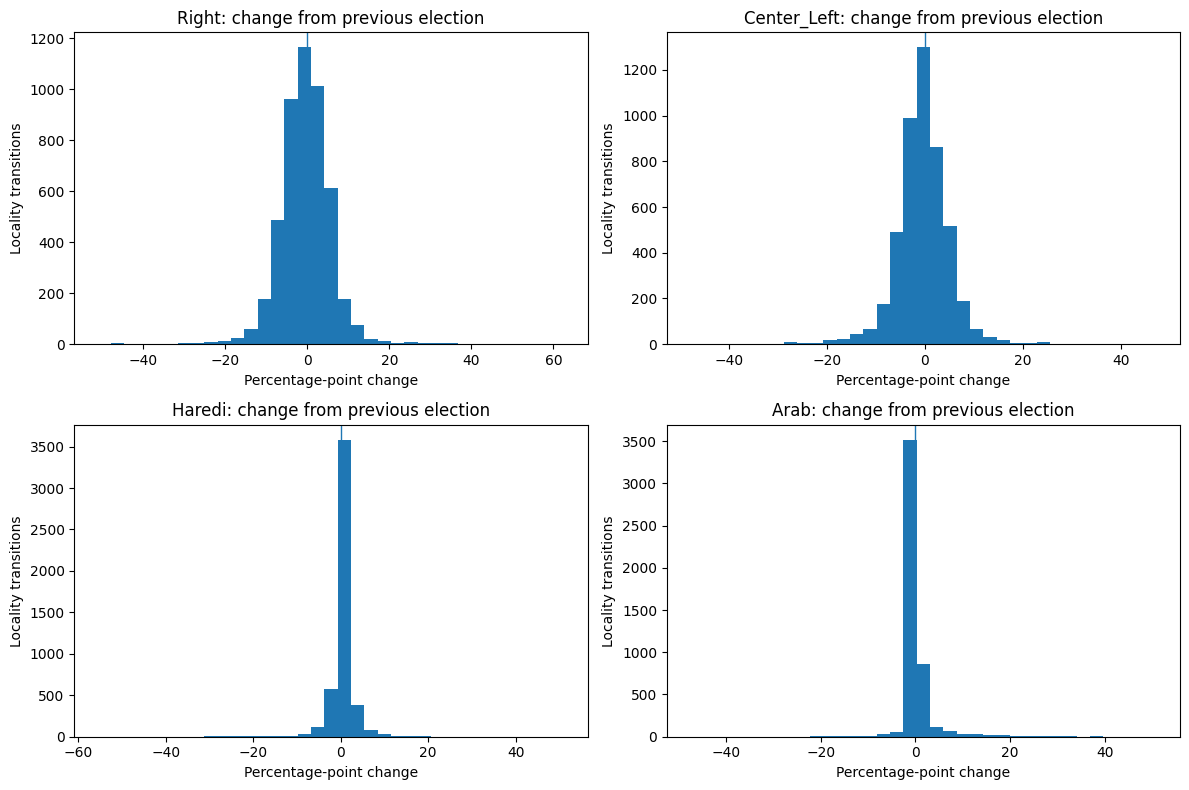

Figure saved to: /content/Election_Bloc_Prediction_Project/reports/figures/bloc_change_distributions.png


In [17]:

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

for ax, bloc in zip(
    axes.flat,
    MODELED_BLOCS,
):
    values = transition_panel[
        f"delta_{bloc}_pct"
    ].dropna()

    ax.hist(
        values,
        bins=35,
    )

    ax.axvline(
        0,
        linewidth=1,
    )

    ax.set_title(
        f"{bloc}: change from previous election"
    )
    ax.set_xlabel("Percentage-point change")
    ax.set_ylabel("Locality transitions")

plt.tight_layout()

DELTA_FIGURE_PATH = (
    FIGURES_DIR
    / "bloc_change_distributions.png"
)

plt.savefig(
    DELTA_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", DELTA_FIGURE_PATH)


## 13. Final panel quality checks

In [18]:

quality_checks = {}

duplicate_transition_count = int(
    transition_panel.duplicated(
        ["locality_symbol", "transition_id"]
    ).sum()
)

quality_checks[
    "duplicate_locality_transition_rows"
] = duplicate_transition_count

if duplicate_transition_count:
    raise ValueError(
        f"Found {duplicate_transition_count} duplicated "
        "locality-transition rows."
    )

missing_target_rows = int(
    transition_panel[
        [
            *current_pct_columns,
            *delta_columns,
            *clr_delta_columns,
        ]
    ].isna().any(axis=1).sum()
)

quality_checks[
    "rows_with_missing_targets"
] = missing_target_rows

if missing_target_rows:
    raise ValueError(
        f"Found {missing_target_rows} rows with missing targets."
    )

unexpected_transition_counts = (
    transition_panel[
        "transition_id"
    ].value_counts()
)

quality_checks[
    "rows_by_transition"
] = {
        str(key): int(value)
        for key, value
        in unexpected_transition_counts.items()
}

quality_checks[
    "max_percentage_delta_sum_error"
] = max_delta_sum_error

quality_checks[
    "max_clr_delta_sum_error"
] = max_clr_delta_sum_error

quality_checks[
    "max_baseline_composition_error"
] = max_baseline_total_error

print("All transition-panel quality checks passed.")
pd.Series(quality_checks, dtype="object")


All transition-panel quality checks passed.


,0
duplicate_locality_transition_rows,0
rows_with_missing_targets,0
rows_by_transition,"{'K22_to_K23': 1213, 'K21_to_K22': 1212, 'K24_..."
max_percentage_delta_sum_error,0.0
max_clr_delta_sum_error,0.0
max_baseline_composition_error,0.0



## 14. Organize and save outputs

The panel contains both predictors and targets.

Later modeling notebooks must explicitly exclude:

- locality identifiers
- current-election result columns
- current-election audit variables
- target deltas

from the feature matrix.


In [19]:

front_columns = [
    "locality_symbol",
    "locality_name",
    "transition_id",
    "previous_election",
    "current_election",
    "previous_election_number",
    "current_election_number",
    "previous_year",
    "current_year",
    "calendar_year_gap",
]

remaining_columns = [
    column
    for column in transition_panel.columns
    if column not in front_columns
]

transition_panel = transition_panel[
    [
        *front_columns,
        *remaining_columns,
    ]
].sort_values(
    [
        "current_election_number",
        "locality_symbol",
    ],
    key=lambda series: (
        pd.to_numeric(
            series,
            errors="coerce",
        )
        if series.name == "locality_symbol"
        else series
    ),
).reset_index(drop=True)

TRANSITION_PANEL_PATH = (
    INTERIM_DIR
    / "election_transition_panel.csv"
)

MATCH_AUDIT_PATH = (
    TABLES_DIR
    / "election_transition_match_audit.csv"
)

UNMATCHED_PATH = (
    TABLES_DIR
    / "unmatched_localities_by_transition.csv"
)

CLR_AUDIT_PATH = (
    TABLES_DIR
    / "clr_transformation_audit.csv"
)

DELTA_SUMMARY_PATH = (
    TABLES_DIR
    / "bloc_delta_descriptive_summary.csv"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_02_summary.json"
)

transition_panel.to_csv(
    TRANSITION_PANEL_PATH,
    index=False,
    encoding="utf-8-sig",
)

transition_match_audit.to_csv(
    MATCH_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

unmatched_localities.to_csv(
    UNMATCHED_PATH,
    index=False,
    encoding="utf-8-sig",
)

clr_audit.to_csv(
    CLR_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

delta_summary.to_csv(
    DELTA_SUMMARY_PATH,
    encoding="utf-8-sig",
)

notebook_summary = {
    "notebook": "02_panel_and_target_engineering",
    "rows_created": int(len(transition_panel)),
    "unique_localities": int(
        transition_panel[
            "locality_symbol"
        ].nunique()
    ),
    "number_of_transitions": int(
        transition_panel[
            "transition_id"
        ].nunique()
    ),
    "rows_by_transition": {
        str(key): int(value)
        for key, value
        in transition_panel[
            "transition_id"
        ].value_counts().items()
    },
    "target_definition": {
        "percentage_point_delta": (
            "current bloc share minus previous bloc share"
        ),
        "clr_delta": (
            "current CLR coordinates minus previous CLR coordinates"
        ),
        "clr_epsilon": CLR_EPSILON,
    },
    "main_baseline": (
        "previous-election persistence baseline"
    ),
    "quality_checks": quality_checks,
    "outputs": {
        "transition_panel": str(
            TRANSITION_PANEL_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "match_audit": str(
            MATCH_AUDIT_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "unmatched_localities": str(
            UNMATCHED_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "clr_audit": str(
            CLR_AUDIT_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "delta_summary": str(
            DELTA_SUMMARY_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "delta_figure": str(
            DELTA_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
    },
}

with NOTEBOOK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        notebook_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:")
for path in [
    TRANSITION_PANEL_PATH,
    MATCH_AUDIT_PATH,
    UNMATCHED_PATH,
    CLR_AUDIT_PATH,
    DELTA_SUMMARY_PATH,
    DELTA_FIGURE_PATH,
    NOTEBOOK_SUMMARY_PATH,
]:
    print("-", path)


Saved:
- /content/Election_Bloc_Prediction_Project/data/interim/election_transition_panel.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/election_transition_match_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/unmatched_localities_by_transition.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/clr_transformation_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/bloc_delta_descriptive_summary.csv
- /content/Election_Bloc_Prediction_Project/reports/figures/bloc_change_distributions.png
- /content/Election_Bloc_Prediction_Project/reports/summaries/notebook_02_summary.json


## 15. Final output preview

In [24]:

preview_columns = [
    "locality_symbol",
    "locality_name",
    "transition_id",
    "previous_election",
    "current_election",
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"current_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"delta_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    "previous_turnout_pct",
    "current_turnout_pct",
    "delta_turnout_pct",
    "baseline_mean_absolute_error",
]

transition_panel[
    preview_columns
].head(10)


,locality_symbol,locality_name,transition_id,previous_election,current_election,previous_Right_pct,previous_Center_Left_pct,previous_Haredi_pct,previous_Arab_pct,current_Right_pct,current_Center_Left_pct,current_Haredi_pct,current_Arab_pct,delta_Right_pct,delta_Center_Left_pct,delta_Haredi_pct,delta_Arab_pct,previous_turnout_pct,current_turnout_pct,delta_turnout_pct,baseline_mean_absolute_error
0,7,שחר,K21_to_K22,Knesset_21,Knesset_22,52.972973,37.567568,9.459459,0.000000,44.289694,42.618384,13.091922,0.000000,-8.683279,5.050817,3.632463,0.00000,71.899225,72.920696,1.021472,4.341640
1,10,תירוש,K21_to_K22,Knesset_21,Knesset_22,62.978723,4.680851,32.340426,0.000000,48.214286,3.571429,48.214286,0.000000,-14.764438,-1.109422,15.873860,0.00000,71.171171,73.795181,2.624010,7.936930
2,11,"ניר ח""ן",K21_to_K22,Knesset_21,Knesset_22,45.138889,54.166667,0.694444,0.000000,33.783784,63.513514,2.252252,0.450450,-11.355105,9.346847,1.557808,0.45045,71.712159,70.689655,-1.022504,5.677553
3,13,חצבה,K21_to_K22,Knesset_21,Knesset_22,18.796992,80.200501,1.002506,0.000000,13.569322,85.545723,0.884956,0.000000,-5.227671,5.345221,-0.117551,0.00000,80.278884,74.302789,-5.976096,2.672611
4,15,נועם,K21_to_K22,Knesset_21,Knesset_22,82.547170,3.773585,13.679245,0.000000,75.555556,6.666667,17.777778,0.000000,-6.991614,2.893082,4.098532,0.00000,71.854305,74.025974,2.171669,3.495807
5,16,בית ניר,K21_to_K22,Knesset_21,Knesset_22,5.471125,94.528875,0.000000,0.000000,3.768116,94.782609,0.289855,1.159420,-1.703009,0.253733,0.289855,1.15942,77.156177,79.405034,2.248857,0.851504
6,18,שדה משה,K21_to_K22,Knesset_21,Knesset_22,32.441472,66.889632,0.668896,0.000000,29.473684,69.824561,0.701754,0.000000,-2.967787,2.934929,0.032858,0.00000,76.884422,76.826196,-0.058226,1.483894
7,21,באר אורה,K21_to_K22,Knesset_21,Knesset_22,36.496350,61.313869,1.703163,0.486618,29.468599,67.874396,1.932367,0.724638,-7.027751,6.560528,0.229204,0.23802,75.636364,72.822300,-2.814064,3.513876
8,22,מקווה ישראל,K21_to_K22,Knesset_21,Knesset_22,39.215686,59.803922,0.980392,0.000000,32.631579,66.315789,1.052632,0.000000,-6.584107,6.511868,0.072239,0.00000,67.105263,63.333333,-3.771930,3.292054
9,23,אמציה,K21_to_K22,Knesset_21,Knesset_22,79.503106,20.496894,0.000000,0.000000,70.072993,27.007299,2.919708,0.000000,-9.430113,6.510405,2.919708,0.00000,73.636364,73.333333,-0.303030,4.715056


In [28]:
from pathlib import Path
from zipfile import ZipFile
from google.colab import files

root = Path("/content/Election_Bloc_Prediction_Project")

file_names = [
    "data/interim/election_transition_panel.csv",
    "reports/tables/election_transition_match_audit.csv",
    "reports/tables/unmatched_localities_by_transition.csv",
    "reports/tables/clr_transformation_audit.csv",
    "reports/tables/bloc_delta_descriptive_summary.csv",
    "reports/tables/transition_panel_quality_checks.csv",
    "reports/figures/bloc_change_distributions.png",
    "reports/summaries/notebook_02_summary.json",
]

zip_path = Path("/content/notebook_02_outputs.zip")

with ZipFile(zip_path, "w") as zip_file:
    for file_name in file_names:
        file_path = root / file_name

        if file_path.exists():
            zip_file.write(
                file_path,
                arcname=file_name,
            )
            print("Added:", file_name)
        else:
            print("Skipped:", file_name)

files.download(str(zip_path))

Added: data/interim/election_transition_panel.csv
Added: reports/tables/election_transition_match_audit.csv
Added: reports/tables/unmatched_localities_by_transition.csv
Added: reports/tables/clr_transformation_audit.csv
Added: reports/tables/bloc_delta_descriptive_summary.csv
Added: reports/tables/transition_panel_quality_checks.csv
Added: reports/figures/bloc_change_distributions.png
Added: reports/summaries/notebook_02_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Notebook 02 completion checklist

This notebook is complete when:

- Four consecutive election transitions are defined.
- Localities are matched using `locality_symbol`.
- Unmatched localities are documented.
- Percentage-point change targets are created.
- CLR and CLR-change targets are created.
- CLR reconstruction is audited.
- The persistence baseline is added.
- Percentage-point deltas sum to zero.
- CLR deltas sum to zero.
- No duplicated locality-transition rows remain.
- All outputs are saved successfully.

The next notebook is:

> `03_eda_and_baselines.ipynb`

It will quantify voting stability, evaluate the persistence baseline, compare it with simpler group-level baselines and determine where meaningful change is available to model.
